## Catastro Minero de Salta

### Notebook 01: EDA y Limpieza de Datos

### Proyecto: Análisis del catastro minero oficial de la provincia de Salta, Argentina

Fuente: Geoportal oficial de Salta

##Autora: Camila Mopty
### Fecha: 2026
--------------------------------------------

## 1. Librerías

In [32]:
#LIBRERÍAS

import subprocess
import os
import warnings
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from pathlib import Path
from datetime import datetime

import geopandas as gpd
from shapely.validation import make_valid

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import folium

## 2. Carga de dataset

In [33]:
# Clonación del repositorio

repo_url = "https://github.com/Camilamop/catastro-minero-salta-mining-registry-salta.git"
repo_name = "catastro-minero-salta-mining-registry-salta"

if not os.path.exists(repo_name):
    subprocess.run(["git", "clone", repo_url], check=True)
    print("Repositorio clonado correctamente.")
else:
    print("El repositorio ya existe en el entorno.")

# Rutas
data_raw = f"https://github.com/Camilamop/catastro-minero-salta-mining-registry-salta.git/data/raw/"
shapefile = f"https://github.com/Camilamop/catastro-minero-salta-mining-registry-salta.git/data/raw/poligonos_adaf55f39328ff45c8c60e94eb13a7a0.shp"

El repositorio ya existe en el entorno.


In [34]:
# geopandas: geospatial data handling (reads shapefiles, handles geometries)
# pyproj: coordinate reference system transformations
# folium: interactive maps
# missingno: missing data visualization

import subprocess, sys

packages = [
    'geopandas',
    'pyproj',
    'folium',
    'missingno',
    'mapclassify',   # required by geopandas .explore()
    'fiona'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✓ Todas las dependencias instaladas correctamente.')

✓ Todas las dependencias instaladas correctamente.


In [35]:
# Leer el shapefile
catastro_minero = gpd.read_file("catastro-minero-salta-mining-registry-salta/data/raw/poligonos_adaf55f39328ff45c8c60e94eb13a7a0.shp",
encoding='latin-1'
)

# Verificar CRS (sistema de coordenadas)
print(catastro_minero.crs)

# Convertir a WGS84 si no está ya
cmin = catastro_minero.to_crs(epsg=4326)

# Exportar a GeoJSON (mantiene geometría)
catastro_minero.to_file("catastro_minero.geojson", driver="GeoJSON")

# Exportar a CSV (sin geometría, para tablas relacionales)
catastro_minero.drop(columns="geometry").to_csv("catastro_minero.csv", index=False)

EPSG:4326


## 3. EDA- Exploración inicial

In [36]:
# Cantidad de columnas y filas del dataset
cmin.shape
cmin.columns

Index(['fid', 'tipo', 'expediente', 'nombre', 'mineral', 'concesiona',
       'estado', 'resolucion', 'fecha_inic', 'departamen', 'municipio',
       'lugar', 'area', 'coordenada', 'geometry'],
      dtype='object')

In [37]:
cmin.geometry.geom_type.unique()

array(['Polygon', 'MultiPolygon'], dtype=object)

In [38]:
#Nombres de columnas y tipo de datos
cmin.dtypes

,0
fid,int32
tipo,object
expediente,object
nombre,object
mineral,object
concesiona,object
estado,object
resolucion,object
fecha_inic,datetime64[ms]
departamen,object


In [39]:
#Primeras columnas
cmin.head(10)

,fid,tipo,expediente,nombre,mineral,concesiona,estado,resolucion,fecha_inic,departamen,municipio,lugar,area,coordenada,geometry
0,21613,Mina,21942,SALRIO 02,"Li,SALINAS",WOMBAT MINERALS S.A.,Vigente,None,2013-03-08,LOS ANDES,TOLAR GRANDE,SALAR DE RÍO GRANDE,"298,2633 ha","MULTIPOLYGON(((2580964.89 7223128,2582213.04 7...","POLYGON ((-68.19725 -25.11323, -68.18488 -25.1..."
1,21614,Manifestacion,825595,LUCRIZARO 2,Li,OLIVER PERALTA LUCRECIA,Vigente,None,2023-09-08,LOS ANDES,TOLAR GRANDE,ARIZARO,"900,4227 ha","MULTIPOLYGON(((2633624.49 7227300,2636467.07 7...","POLYGON ((-67.67564 -25.07183, -67.64747 -25.0..."
2,21615,Cantera,23265,METAN VIEJO,ÁRIDOS,VIALMANI S.A.,Vigente,None,2017-09-25,METÁN,SAN JOSÉ DE METÁN,None,"24,5410 ha","MULTIPOLYGON(((3603884.84 7176937.43,3603849.5...","POLYGON ((-64.9665 -25.52872, -64.96685 -25.52..."
3,21616,Manifestacion,824686,LUCAS POZUELOS II,Cu,PERALTA WALTER LUCAS,Vigente,None,2023-08-31,LOS ANDES,SAN ANTONIO DE LOS COBRES,POZUELOS,"426,8000 ha","MULTIPOLYGON(((3424576 7294298,3424848 7294298...","POLYGON ((-66.74397 -24.47107, -66.74129 -24.4..."
4,21617,Mina,22869,GONZALO I,"Au,Cu",CORRIENTE ARGENTINA S.A.,Vigente,None,2016-12-28,LOS ANDES,TOLAR GRANDE,TACA TACA,"2094,9707 ha","MULTIPOLYGON(((2593248.37 7298440.68,2599897 7...","POLYGON ((-68.0805 -24.4327, -68.01494 -24.432..."
5,21618,Mina,1232,CITA,BORATOS,BORAX ARGENTINA S.A.,Vigente,None,1941-06-16,LOS ANDES,SAN ANTONIO DE LOS COBRES,SALAR DE PASTOS GRANDES,"100,9902 ha","MULTIPOLYGON(((3433963.65 7270192.640000001,34...","POLYGON ((-66.65251 -24.6891, -66.65307 -24.70..."
6,21619,Manifestacion,24402,ANA 7,"Ag,Au,BORATOS,Cu,Li",NEGRIZ GANDOLA ANA ISABEL,Vigente,None,2020-07-24,LOS ANDES,TOLAR GRANDE,POCITOS,"2686,6520 ha","MULTIPOLYGON(((3384316.63 7320940.97,3387805 7...","POLYGON ((-67.13888 -24.2281, -67.10454 -24.22..."
7,21620,Manifestacion,810481,KAIRUS III,"Au,Cu",None,Vigente,None,2023-04-28,ROSARIO DE LERMA,CAMPO QUIJANO,SANTA ROSA DE TASTIL,"2405,3080 ha","MULTIPOLYGON(((3509262.88 7297450.5,3514010.96...","POLYGON ((-65.90865 -24.44441, -65.86182 -24.4..."
8,21621,Mina,18829,NORMA EDITH,BORATOS,NRG METALS ARGENTINA S.A.,Vigente,None,2007-06-21,LOS ANDES,SAN ANTONIO DE LOS COBRES,SALAR DEL HOMBRE MUERTO,"285,3886 ha","MULTIPOLYGON(((3391416.63 7202939.87,3393107.8...","POLYGON ((-67.07815 -25.2937, -67.06135 -25.29..."
9,21622,Manifestacion,746319,QUEVARITA II,"Ag,Pb,PERLITA,Zn",ANIS ALGARRA RAUL MARIO,Vigente,None,2021-09-01,LOS ANDES,SAN ANTONIO DE LOS COBRES,QUIRON,"173,1420 ha","MULTIPOLYGON(((3414600.14 7301526.5,3414679.57...","POLYGON ((-66.84193 -24.4053, -66.84121 -24.41..."


In [40]:
cmin.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 4104 entries, 0 to 4103
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fid         4104 non-null   int32         
 1   tipo        4104 non-null   object        
 2   expediente  4102 non-null   object        
 3   nombre      4006 non-null   object        
 4   mineral     3500 non-null   object        
 5   concesiona  3747 non-null   object        
 6   estado      4104 non-null   object        
 7   resolucion  95 non-null     object        
 8   fecha_inic  3928 non-null   datetime64[ms]
 9   departamen  4103 non-null   object        
 10  municipio   4050 non-null   object        
 11  lugar       3537 non-null   object        
 12  area        4104 non-null   object        
 13  coordenada  4104 non-null   object        
 14  geometry    4104 non-null   geometry      
dtypes: datetime64[ms](1), geometry(1), int32(1), object(12)
memory u

In [41]:
cmin.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
fid,4104.0,NaN,NaN,NaN,22664.5,20613.0,21638.75,22664.5,23690.25,24716.0,1184.867081
tipo,4104,8,Mina,1631,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expediente,4102,3950,033-160210/2021,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre,4006,3294,Cateo,291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mineral,3500,243,ÁRIDOS,501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
concesiona,3747,787,LITHIUM S CORPORATION S.A.,234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estado,4104,4,Vigente,3932,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolucion,95,79,"262/2016,112/2020",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_inic,3928,NaN,NaN,NaN,2009-12-11 07:19:11.120000,1900-05-04 00:00:00,2007-06-27 00:00:00,2016-12-28 00:00:00,2022-10-27 00:00:00,2025-12-11 00:00:00,NaN
departamen,4103,23,LOS ANDES,2808,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# Valores de tipo y de estado

print(f'tipo: {cmin['tipo'].unique()}')
print(f'estado: {cmin['estado'].unique()}')


tipo: ['Mina' 'Manifestacion' 'Cantera' 'Cateo' 'Grupo Minero' 'Convenio'
 'Servidumbre' 'Zona de Investigación Geológica Minera']
estado: ['Vigente' 'Vacante' 'Anulación de registro sin publicar (REMSa)'
 'Anulación de registro sin publicar']


In [43]:
# Cantidad y porcentaje de nulos por columna

nulos = pd.DataFrame({
    'nulos': cmin.isnull().sum(),
    'porcentaje':  (cmin.isnull().sum() / len(cmin) * 100).round(1),
    'vacios': [(cmin[c].astype(str).str.strip() == '').sum() for c in cmin.columns],
}).sort_values('porcentaje', ascending=False)

print(nulos)

            nulos  porcentaje  vacios
resolucion   4009        97.7       0
mineral       604        14.7       0
lugar         567        13.8       0
concesiona    357         8.7       0
fecha_inic    176         4.3       0
nombre         98         2.4       0
municipio      54         1.3       0
estado          0         0.0       0
fid             0         0.0       0
tipo            0         0.0       0
expediente      2         0.0       0
departamen      1         0.0       0
area            0         0.0       0
coordenada      0         0.0       0
geometry        0         0.0       0


## **4. Preparación y transformación del dataset**

In [44]:
# Transformación: campo 'area' a float
# Paso 1: eliminar 'ha' del final
# Paso 2: reemplazar ',' por '.'
# Paso 3: convertir a float

cmin['area_ha'] = (
    cmin['area']
    .str.replace(' ha', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

# Verificación
print("Muestra de conversión:")
comparacion = cmin[['area', 'area_ha']].dropna().head(8)
print(comparacion.to_string())
print(f"\nTipo de dato: {cmin['area_ha'].dtype}")
print(f"Nulos:        {cmin['area_ha'].isna().sum()}")
print(f"Rango:        {cmin['area_ha'].min():.2f} ha — {cmin['area_ha'].max():,.2f} ha")

Muestra de conversión:
           area    area_ha
0   298,2633 ha   298.2633
1   900,4227 ha   900.4227
2    24,5410 ha    24.5410
3   426,8000 ha   426.8000
4  2094,9707 ha  2094.9707
5   100,9902 ha   100.9902
6  2686,6520 ha  2686.6520
7  2405,3080 ha  2405.3080

Tipo de dato: float64
Nulos:        0
Rango:        0.01 ha — 80,031.94 ha


In [45]:
# Creación de subconjunto para análisis de minerales
# Criterio: excluir registros donde 'mineral' es NaN o string vacío


cmin_completo = cmin[
    cmin['mineral'].notna() &
    (cmin['mineral'].str.strip() != '')
].copy()

# Verificación
print(f"Dataset completo:           {len(cmin):,} registros")
print(f"Dataset con mineral:        {len(cmin_completo):,} registros")
print(f"Registros excluidos:        {len(cmin) - len(cmin_completo):,}")

print(f"\nValores y conteo de 'mineral' en cmin_completo:")
print(cmin_completo['mineral'].value_counts().to_string())

Dataset completo:           4,104 registros
Dataset con mineral:        3,500 registros
Registros excluidos:        604

Valores y conteo de 'mineral' en cmin_completo:
mineral
ÁRIDOS                                                             501
Cu                                                                 335
Li                                                                 321
Au,Cu                                                              205
K,Li,SALINAS                                                       153
BORATOS                                                            144
DIATOMITAS                                                         119
BORATOS,Li                                                         102
Li,SALINAS                                                         100
K,Li                                                                99
Ag,Au,Cu                                                            96
BORATOS,K,Li                              

In [46]:
cmin_completo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 3500 entries, 0 to 4103
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fid         3500 non-null   int32         
 1   tipo        3500 non-null   object        
 2   expediente  3498 non-null   object        
 3   nombre      3428 non-null   object        
 4   mineral     3500 non-null   object        
 5   concesiona  3247 non-null   object        
 6   estado      3500 non-null   object        
 7   resolucion  90 non-null     object        
 8   fecha_inic  3366 non-null   datetime64[ms]
 9   departamen  3500 non-null   object        
 10  municipio   3499 non-null   object        
 11  lugar       3228 non-null   object        
 12  area        3500 non-null   object        
 13  coordenada  3500 non-null   object        
 14  geometry    3500 non-null   geometry      
 15  area_ha     3500 non-null   float64       
dtypes: datetime64[ms](1),

###Clasificación

In [47]:
# Clasificación one-hot
# Detecta presencia de Li, Cu , Au en el campo mineral

mineral_col = cmin_completo['mineral'].fillna('')

cmin_completo['minerales_criticos'] = (
    mineral_col.str.contains('Li', case=False) |
    mineral_col.str.contains('Cu', case=False) |
    mineral_col.str.contains('Au', case=False)
)

In [48]:
cmin_completo.head(5)

,fid,tipo,expediente,nombre,mineral,concesiona,estado,resolucion,fecha_inic,departamen,municipio,lugar,area,coordenada,geometry,area_ha,minerales_criticos
0,21613,Mina,21942,SALRIO 02,"Li,SALINAS",WOMBAT MINERALS S.A.,Vigente,None,2013-03-08,LOS ANDES,TOLAR GRANDE,SALAR DE RÍO GRANDE,"298,2633 ha","MULTIPOLYGON(((2580964.89 7223128,2582213.04 7...","POLYGON ((-68.19725 -25.11323, -68.18488 -25.1...",298.2633,True
1,21614,Manifestacion,825595,LUCRIZARO 2,Li,OLIVER PERALTA LUCRECIA,Vigente,None,2023-09-08,LOS ANDES,TOLAR GRANDE,ARIZARO,"900,4227 ha","MULTIPOLYGON(((2633624.49 7227300,2636467.07 7...","POLYGON ((-67.67564 -25.07183, -67.64747 -25.0...",900.4227,True
2,21615,Cantera,23265,METAN VIEJO,ÁRIDOS,VIALMANI S.A.,Vigente,None,2017-09-25,METÁN,SAN JOSÉ DE METÁN,None,"24,5410 ha","MULTIPOLYGON(((3603884.84 7176937.43,3603849.5...","POLYGON ((-64.9665 -25.52872, -64.96685 -25.52...",24.5410,False
3,21616,Manifestacion,824686,LUCAS POZUELOS II,Cu,PERALTA WALTER LUCAS,Vigente,None,2023-08-31,LOS ANDES,SAN ANTONIO DE LOS COBRES,POZUELOS,"426,8000 ha","MULTIPOLYGON(((3424576 7294298,3424848 7294298...","POLYGON ((-66.74397 -24.47107, -66.74129 -24.4...",426.8000,True
4,21617,Mina,22869,GONZALO I,"Au,Cu",CORRIENTE ARGENTINA S.A.,Vigente,None,2016-12-28,LOS ANDES,TOLAR GRANDE,TACA TACA,"2094,9707 ha","MULTIPOLYGON(((2593248.37 7298440.68,2599897 7...","POLYGON ((-68.0805 -24.4327, -68.01494 -24.432...",2094.9707,True


In [49]:
# Geometrías válidas

print(f"Válidas:   {cmin_completo.geometry.is_valid.sum()}")
print(f"Inválidas: {(~cmin_completo.is_valid).sum()}")
print(f"Vacías:    {cmin_completo.is_empty.sum()}")
print(f"Nulas:     {cmin_completo.isna().sum()}")

Válidas:   3498
Inválidas: 2
Vacías:    0
Nulas:     fid                      0
tipo                     0
expediente               2
nombre                  72
mineral                  0
concesiona             253
estado                   0
resolucion            3410
fecha_inic             134
departamen               0
municipio                1
lugar                  272
area                     0
coordenada               0
geometry                 0
area_ha                  0
minerales_criticos       0
dtype: int64


In [50]:
# Tratamiento de geometrias inválidas

from shapely.validation import explain_validity

mask_invalidas = ~cmin_completo.geometry.is_valid

for idx, row in cmin_completo[mask_invalidas].iterrows():
    print(f"fid: {row['fid']}")
    print(f"nombre:       {row['nombre']}")
    print(f"problema:     {explain_validity(row.geometry)}")
    print()

fid: 21536
nombre:       PLAYA
problema:     Self-intersection[-66.6787951639559 -24.7668254463655]

fid: 21555
nombre:       MARIDEL
problema:     Self-intersection[-66.7085658422087 -24.7671982461615]



In [51]:
#Como ambas tienen self-intersections (error de dibujo) se convierten a válidas

from shapely.validation import make_valid

mask_invalidas = ~cmin_completo.geometry.is_valid
cmin_completo.loc[mask_invalidas, 'geometry'] = (
    cmin_completo.loc[mask_invalidas, 'geometry']
    .apply(make_valid)
)
print(f"Inválidas: {(~cmin_completo.is_valid).sum()}")

Inválidas: 0


In [52]:
# Cuenta pedimentos con minerales críticos
cmin_completo.minerales_criticos.value_counts()

,count
minerales_criticos,
True,2396
False,1104


In [53]:
from google.colab import files

# Exportar en GeoJSON y cvs
cmin_completo.to_file('catastro_minero_clean.geojson', driver='GeoJSON')
files.download('catastro_minero_clean.geojson')

cmin_completo.drop(columns='geometry').to_csv('catastro_minero_clean.csv', index=False)
files.download('catastro_minero_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Gráficos

**5.1. Pedimentos por departamentos - gráfico de barras**

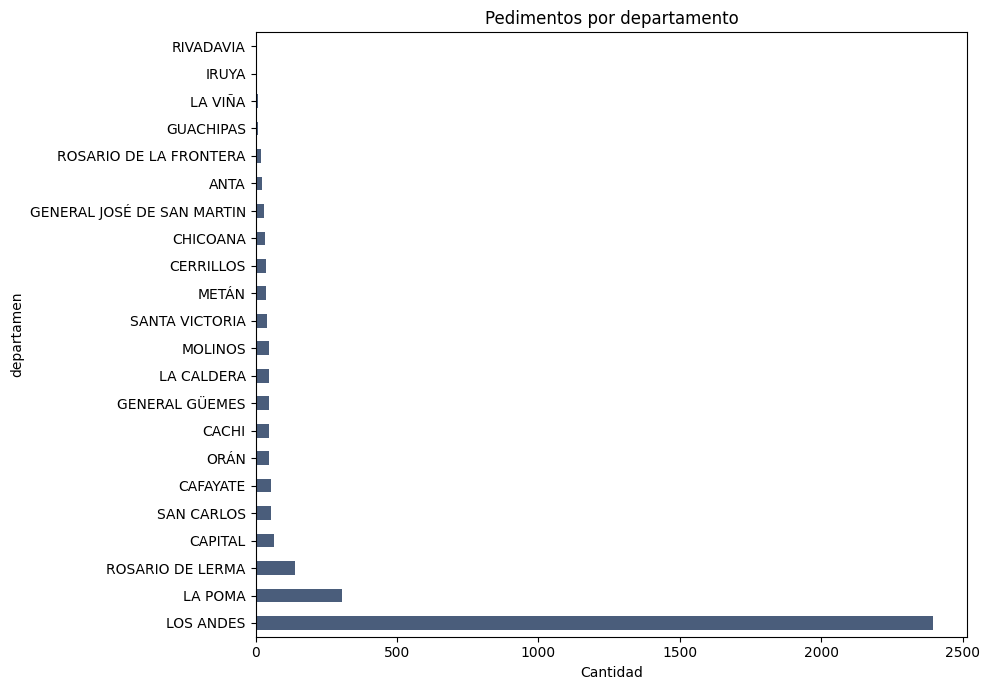

In [54]:
# Grafico 1 Distribución por departamentos grafico de barras
cmin_completo['departamen'].value_counts().plot(
    kind='barh', figsize=(10, 7), color='#4a5d7b'
)
plt.title('Pedimentos por departamento')
plt.xlabel('Cantidad')
plt.tight_layout()
plt.show()

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

**5.2. Pedimentos por departamentos - gráfico de tortas**

In [56]:
# Grafico 2: Pedimentos por departamentos en gráfico de tortas
exp_depto = (
    cmin_completo['departamen']
    .value_counts()
)

# Agrupar departamentos menores en 'Otros'
threshold = exp_depto.sum() * 0.03
otros = exp_depto[exp_depto < threshold].sum()
exp_depto_plot = exp_depto[exp_depto >= threshold].copy()
if otros > 0:
    exp_depto_plot['Otros'] = otros

fig = go.Figure(go.Pie(
    labels=exp_depto_plot.index,
    values=exp_depto_plot.values,
    hole=0,
    marker=dict(colors=['#4a5d7b', '#262134', '#899eac', '#3e4a38',
                         '#4a543c', '#8E44AD', '#C0392B']),
    textinfo='percent+label',
    textfont=dict(size=11),
))

fig.update_layout(
    title=dict(
        text='Cantidad de expedientes según departamento',
        font=dict(size=15, color='#2C3E50'),
        x=0.5
    ),
    legend=dict(orientation='v', x=1.05),
    margin=dict(t=60, b=20, l=20, r=150),
    width=600, height=420
)

fig.show()

**5.3. Pedimentos con minerales críticos por departamento - gráfico de barras apiladas**

In [57]:
# Gráfico 3: Cantidad de pedimentos con mínerales críticos (Li, Cu, Au) por departamento

sup_depto = (
    cmin_completo
    .groupby(['departamen', 'minerales_criticos'])['area_ha']
    .sum()
    .reset_index()
)

# Solo top 8 departamentos por superficie total
top_deptos = (
    cmin_completo.groupby('departamen')['area_ha']
    .sum()
    .nlargest(8)
    .index.tolist()
)

sup_depto_top = sup_depto[sup_depto['departamen'].isin(top_deptos)]

# Separar SI y NO
sup_si = sup_depto_top[sup_depto_top['minerales_criticos'] == True].set_index('departamen')['area_ha']
sup_no = sup_depto_top[sup_depto_top['minerales_criticos'] == False].set_index('departamen')['area_ha']

# Ordenar por superficie total descendente
orden = (sup_si.fillna(0) + sup_no.fillna(0)).sort_values(ascending=True).index

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerales críticos (Li, Cu o Au)',
    y=orden,
    x=[sup_si.get(d, 0) for d in orden],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(orden),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=orden,
    x=[sup_no.get(d, 0) for d in orden],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(orden),
    textposition='inside'
))

# Etiquetas
for depto in orden:
    val_si = sup_si.get(depto, 0)
    val_no = sup_no.get(depto, 0)
    total  = val_si + val_no

    label_si = f"{val_si/1e6:.2f}M ha" if val_si >= 1e6 else f"{val_si:,.0f} ha".replace(',', '.')
    label_no = f"{val_no/1e6:.2f}M ha" if val_no >= 1e6 else f"{val_no:,.0f} ha".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=depto,
        text=f"<b>{label_si}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=1
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=depto,
        text=f"<b>{label_no}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=-1
    )

fig.update_layout(
    barmode='stack',
    separators='.',
    title=dict(
        text='Superficie (ha) con y sin minerales críticos por departamento',
        font=dict(size=15, color='#2C3E50'),
        x=0.15
    ),
    xaxis=dict(
        title='Hectáreas',
        tickformat=',.0f',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(title='', showgrid=False),
    legend=dict(orientation='h', y=-0.15),
    margin=dict(t=60, b=80, l=180, r=200),
    width=950, height=500,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

**5.4. Pedimentos por año de iniciación (2009-2025) con mínerales críticos**

In [58]:
# Gráfico 4: Pedimentos por año de iniciación a partir de 2009

exp_anio = (
    cmin_completo[cmin_completo['fecha_inic'].notna()]
    .assign(anio=cmin_completo['fecha_inic'].dt.year)
    .query('anio >= 2009')
    .groupby(['anio', 'minerales_criticos'])
    .size()
    .reset_index(name='cantidad')
)

años   = sorted(exp_anio['anio'].unique(), reverse=True)
con    = exp_anio[exp_anio['minerales_criticos'] == True].set_index('anio')['cantidad']
sin    = exp_anio[exp_anio['minerales_criticos'] == False].set_index('anio')['cantidad']
totales = {a: con.get(a, 0) + sin.get(a, 0) for a in años}

fig = go.Figure()

fig.add_trace(go.Bar(
    name='Con minerale críticos (Li, Cu o Au)',
    y=años,
    x=[con.get(a, 0) for a in años],
    orientation='h',
    marker_color='#C0392B',
    text=[''] * len(años),
    textposition='inside'
))

fig.add_trace(go.Bar(
    name='Sin minerales críticos',
    y=años,
    x=[sin.get(a, 0) for a in años],
    orientation='h',
    marker_color='#E8834A',
    text=[''] * len(años),
    textposition='inside'
))

# Etiquetas
for anio in años:
    val_con = con.get(anio, 0)
    val_sin = sin.get(anio, 0)
    total   = totales[anio]

    label_con = f"{val_con/1e6:.2f}M" if val_con >= 1e6 else f"{val_con:,.0f}".replace(',', '.')
    label_sin = f"{val_sin/1e6:.2f}M" if val_sin >= 1e6 else f"{val_sin:,.0f}".replace(',', '.')

    # Etiqueta roja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_con}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='bottom',
        font=dict(size=10, color='#C0392B'),
        xshift=6,
        yshift=-4
    )

    # Etiqueta naranja
    fig.add_annotation(
        x=total, y=anio,
        text=f"<b>{label_sin}</b>",
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=10, color='#E8834A'),
        xshift=6,
        yshift=4
    )

fig.update_layout(
    barmode='stack',
    separators='.,',
    title=dict(
        text='Expedientes por año — con y sin minerales críticos',
        font=dict(size=15, color='#2C3E50'),
        x=0.05 # Changed x to 0.05 to add space to the left
    ),
    xaxis=dict(
        title='Cantidad de expedientes',
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        griddash='dot'
    ),
    yaxis=dict(
        title='',
        tickmode='array',
        tickvals=años,
        ticktext=[str(int(a)) for a in años],
        categoryorder='array',
        categoryarray=años
    ),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=80, l=60, r=120),
    width=850, height=600,
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

**5.5. Top 20 actores con mayor cantidad de pedimentos y con pedimentos con minerales críticos**

In [59]:
# Top 20 actores por cantidad de pedimentos y con pedimentos con minerales críticos
top20_exp = (
    cmin_completo[cmin_completo['concesiona'].notna()]
    .groupby('concesiona')
    .agg(
        expedientes=('concesiona', 'count'),
        criticos=('minerales_criticos', 'sum')
    )
    .reset_index()
    .nlargest(20, 'expedientes')
)

top20_exp['criticos'] = top20_exp['criticos'].astype(int)

# Capitalizar las etiquetas
top20_exp['concesiona_label'] = top20_exp['concesiona'].str.title()

fig = px.treemap(
    top20_exp,
    path=['concesiona_label'],
    values='expedientes',
    color='criticos',
    color_continuous_scale='YlOrRd',
    range_color=[0, top20_exp['criticos'].max()],
    title='Top 20 actores por cantidad de expedientes',
    custom_data=['expedientes', 'criticos'],
 )
fig.update_traces(
    texttemplate='<b>%{label}</b><br>%{value} exp.',
    textfont=dict(size=11),
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Expedientes totales: %{customdata[0]}<br>'
        'Con minerales críticos: %{customdata[1]}'
        '<extra></extra>'
    )
)
fig.update_layout(
    title=dict(font=dict(size=15, color='#2C3E50'), x=0.05),
    coloraxis_colorbar=dict(
        title=dict(
            text='Expedientes<br>con minerales<br>críticos',
            font=dict(size=11, color='#2C3E50')
        ),
        tickfont=dict(size=10),
        thickness=15,
        len=0.8,
        x=1.02
    ),
    margin=dict(t=60, b=20, l=10, r=120),
    width=1000, height=500,
    showlegend=False
)
fig.show()

**5.6. Top 20 actores con mayor superficie según pedimentos**

In [60]:
# Grafico 5: Top 20 actores por superficie
top20_exp = (
    cmin_completo[cmin_completo['concesiona'].notna()]
    .groupby('concesiona')
    .agg(
        expedientes=('concesiona', 'count'),
        ha=('area_ha', 'sum')
    )
    .reset_index()
    .nlargest(20, 'expedientes')
)

top20_exp['ha'] = top20_exp['ha'].astype(float)

# Capitalizar las etiquetas
top20_exp['concesiona_label'] = top20_exp['concesiona'].str.title()

fig = px.treemap(
    top20_exp,
    path=['concesiona_label'],
    values='expedientes',
    color='ha',
    color_continuous_scale='Purples',
    range_color=[0, top20_exp['ha'].max()],
    title='Top 20 actores por superficie',
    custom_data=['expedientes', 'ha'],
 )
fig.update_traces(
    texttemplate='<b>%{label}</b><br>%{value} exp.',
    textfont=dict(size=11),
    hovertemplate=(
        '<b>%{label}</b><br>'
        'Expedientes totales: %{customdata[0]}<br>'
        'Superficie total (ha): %{customdata[1]:,.0f}'
        '<extra></extra>'
    )
)
fig.update_layout(
    title=dict(font=dict(size=15, color='#2C3E50'), x=0.05),
    coloraxis_colorbar=dict(
        title=dict(
            text='Superficie total (ha)',
            font=dict(size=11, color='#2C3E50')
        ),
        tickfont=dict(size=10),
        thickness=15,
        len=0.8,
        x=1.02
    ),
    margin=dict(t=60, b=20, l=10, r=120),
    width=1000, height=500,
    showlegend=False
)
fig.show()

**5.7. Mapa con pedimentos con minerales críticos y sin minerales críticos**

In [61]:
import geopandas as gpd
from shapely import wkt
import folium

# --- 1. Convert WKT strings to geometry objects ---
# The 'geometry' column already contains shapely geometry objects, so no need for wkt.loads
gdf = gpd.GeoDataFrame(
    cmin_completo[cmin_completo['geometry'].notna()].copy(),
    geometry=cmin_completo.loc[
        cmin_completo['geometry'].notna(), 'geometry'
    ],
    crs='EPSG:4326'  # WGS84, the CRS of the original dataset
)

# Convert Timestamp objects to string to make them JSON serializable
for col in gdf.select_dtypes(include=['datetime64']).columns:
    gdf[col] = gdf[col].astype(str)

# --- 2. Define color mapping ---
# #C0392B (dark red) = critical minerals
# #E8834A (orange) = without critical minerals
def style_function(feature):
    is_critical = feature['properties']['minerales_criticos']
    color = '#C0392B' if is_critical else '#E8834A'
    return {
        'fillColor': color,
        'color': color,
        'weight': 1,
        'fillOpacity': 0.6
    }

# --- 3. Build the map centered on Salta ---
# Centroid calculated from the data for automatic framing
center_lat = gdf.geometry.centroid.y.mean()
center_lon = gdf.geometry.centroid.x.mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles='CartoDB positron'  # neutral background, ideal for thematic data
)

# --- 4. Add polygons to map ---
folium.GeoJson(
    gdf,
    style_function=style_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['nombre', 'concesiona', 'mineral', 'minerales_criticos', 'fecha_inic'], # Include fecha_inic
        aliases=['Nombre:', 'Titular:', 'Mineral:', 'Mineral crítico:', 'Fecha Inicio:'],
        sticky=True
    )
).add_to(m)

# --- 5. Add legend ---
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 6px;
            box-shadow: 0 2px 6px rgba(0,0,0,0.3);
            font-family: Arial, sans-serif; font-size: 13px;">
    <b>Minerales críticos</b><br>
    <i style="background:#C0392B; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> Sí<br>
    <i style="background:#E8834A; width:14px; height:14px;
       display:inline-block; border-radius:2px; margin-right:6px;"></i> No
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m

Output hidden; open in https://colab.research.google.com to view.